# Classical Time Series Models: ARIMA and SARIMA

## ARIMA Models 

### Fitting ARIMA on Air Passengers

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from statsmodels.datasets import get_rdataset
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tools.sm_exceptions import ValueWarning, ConvergenceWarning
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pathlib import Path
import sys

sys.path.insert(0, str(Path().resolve().parent))
from config import FIGURES, RANDOM_SEED

# ── Reload data (as prepared in Chapter 2) ────────────────────────────────
air = get_rdataset("AirPassengers", "datasets").data
air.columns = ["time", "passengers"]
air["date"] = pd.date_range(start="1949-01", periods=len(air), freq="MS")
air = air.set_index("date")["passengers"].rename("passengers")
log_air = np.log(air)

# ── Set frequency on index ─────────────────────────────────────────────────
log_air.index = log_air.index.to_period('M').to_timestamp('M')

# ── Train/test split: hold out final 24 months ────────────────────────────
HOLDOUT = 24
train_air = log_air.iloc[:-HOLDOUT]
test_air  = log_air.iloc[-HOLDOUT:]

# ── Fit ARIMA(1,1,1) ──────────────────────────────────────────────────────
with warnings.catch_warnings():
    warnings.simplefilter("ignore", ValueWarning)
    warnings.simplefilter("ignore", ConvergenceWarning)
    arima111 = ARIMA(train_air, order=(1, 1, 1)).fit()
print(arima111.summary())

# ── Grid search over (p, q) with d=1 ──────────────────────────────────────
results_grid = {}
for p in range(0, 4):
    for q in range(0, 4):
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", ValueWarning)
                warnings.simplefilter("ignore", ConvergenceWarning)
                m = ARIMA(train_air, order=(p, 1, q)).fit()
            results_grid[(p, q)] = {"AIC": m.aic, "BIC": m.bic}
        except Exception:
            pass

grid_df = pd.DataFrame(results_grid).T
grid_df.index.names = ["p", "q"]
print("\nARIMA(p,1,q) grid — AIC and BIC:")
print(grid_df.sort_values("AIC").head(8).round(2).to_string())

# ── Select best order by AIC ───────────────────────────────────────────────
best_pq = grid_df["AIC"].idxmin()
print(f"\nBest order by AIC: ARIMA({best_pq[0]}, 1, {best_pq[1]})")

                               SARIMAX Results                                
Dep. Variable:             passengers   No. Observations:                  120
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 103.840
Date:                Tue, 28 Apr 2026   AIC                           -201.680
Time:                        18:47:04   BIC                           -193.342
Sample:                    01-31-1949   HQIC                          -198.294
                         - 12-31-1958                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5762      0.191     -3.015      0.003      -0.951      -0.202
ma.L1          0.8348      0.117      7.133      0.000       0.605       1.064
sigma2         0.0102      0.002      5.556      0.0

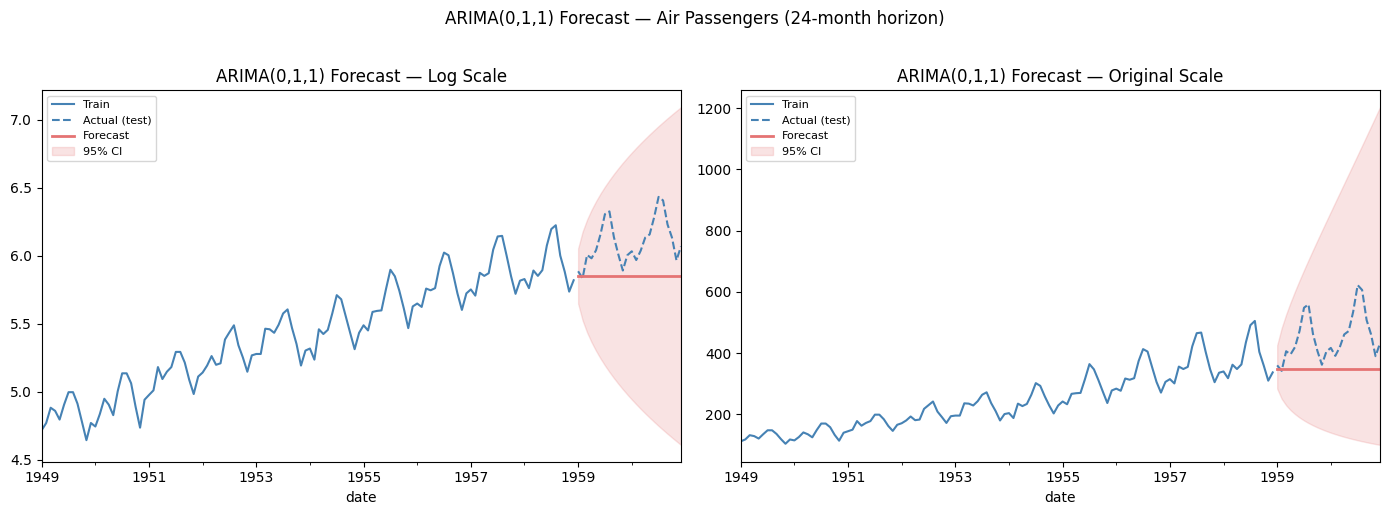

ARIMA(0,1,1) — 24-month out-of-sample forecast:
  MAE  : 105.08 thousand passengers
  RMSE : 128.53 thousand passengers
  MAPE : 21.30%


In [2]:
# ── Fit best non-seasonal model (ARIMA(0,1,1) — parsimonious choice) ──────
arima_best = ARIMA(train_air, order=(0, 1, 1)).fit()

# ── In-sample fit and forecast ────────────────────────────────────────────
forecast_obj = arima_best.get_forecast(steps=HOLDOUT)
fc_mean      = forecast_obj.predicted_mean
fc_ci        = forecast_obj.conf_int(alpha=0.05)

# Back-transform from log scale
fc_mean_orig = np.exp(fc_mean)
fc_ci_orig   = np.exp(fc_ci)
test_orig    = np.exp(test_air)
train_orig   = np.exp(train_air)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log scale
ax = axes[0]
train_air.plot(ax=ax, color="steelblue", lw=1.5, label="Train")
test_air.plot(ax=ax, color="steelblue", lw=1.5, linestyle="--", label="Actual (test)")
fc_mean.plot(ax=ax, color="#E57373", lw=2, label="Forecast")
ax.fill_between(fc_ci.index, fc_ci.iloc[:, 0], fc_ci.iloc[:, 1],
                color="#E57373", alpha=0.2, label="95% CI")
ax.set_title("ARIMA(0,1,1) Forecast — Log Scale")
ax.legend(fontsize=8)

# Original scale
ax = axes[1]
train_orig.plot(ax=ax, color="steelblue", lw=1.5, label="Train")
test_orig.plot(ax=ax, color="steelblue", lw=1.5, linestyle="--", label="Actual (test)")
fc_mean_orig.plot(ax=ax, color="#E57373", lw=2, label="Forecast")
ax.fill_between(fc_ci_orig.index,
                fc_ci_orig.iloc[:, 0], fc_ci_orig.iloc[:, 1],
                color="#E57373", alpha=0.2, label="95% CI")
ax.set_title("ARIMA(0,1,1) Forecast — Original Scale")
ax.legend(fontsize=8)

plt.suptitle("ARIMA(0,1,1) Forecast — Air Passengers (24-month horizon)", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "ch03_arima_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Forecast accuracy ──────────────────────────────────────────────────────
mae  = mean_absolute_error(test_orig, fc_mean_orig)
rmse = np.sqrt(mean_squared_error(test_orig, fc_mean_orig))
mape = np.mean(np.abs((test_orig.values - fc_mean_orig.values) / test_orig.values)) * 100

print(f"ARIMA(0,1,1) — 24-month out-of-sample forecast:")
print(f"  MAE  : {mae:.2f} thousand passengers")
print(f"  RMSE : {rmse:.2f} thousand passengers")
print(f"  MAPE : {mape:.2f}%")

### Residual Diagnostics

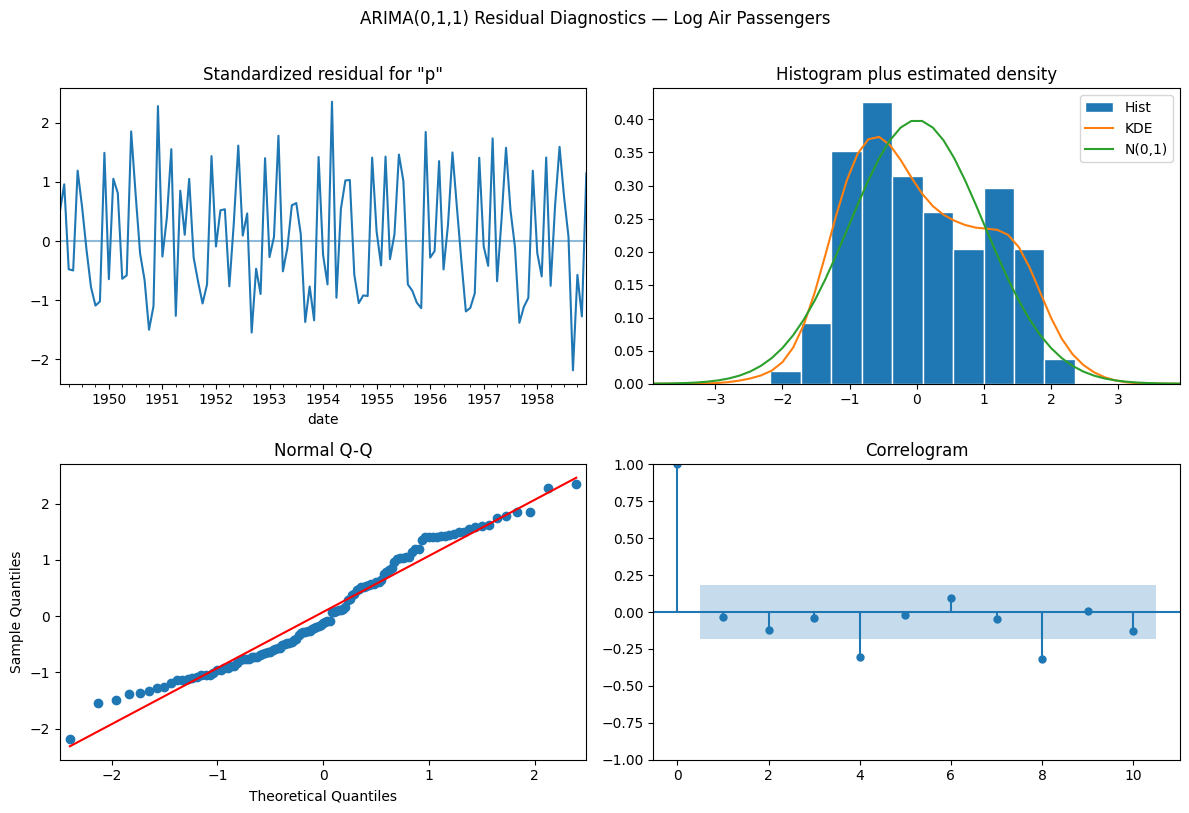

Ljung-Box test on ARIMA(0,1,1) residuals:
    lb_stat  lb_pvalue
6    0.2416     0.9997
12   0.8307     1.0000
18   1.2902     1.0000
24   2.2125     1.0000


In [3]:
from statsmodels.stats.diagnostic import acorr_ljungbox

fig = arima_best.plot_diagnostics(figsize=(12, 8))
fig.suptitle("ARIMA(0,1,1) Residual Diagnostics — Log Air Passengers", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / "ch03_arima_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

# Ljung-Box test on residuals
lb_resid = acorr_ljungbox(arima_best.resid.dropna(),
                          lags=[6, 12, 18, 24], return_df=True)
print("Ljung-Box test on ARIMA(0,1,1) residuals:")
print(lb_resid.round(4).to_string())

## Seasonal ARIMA (SARIMA)

### The SARIMA Framework

In [4]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ── Fit the airline model ─────────────────────────────────────────────────
sarima_011_011 = SARIMAX(
    train_air,
    order=(0, 1, 1),
    seasonal_order=(0, 1, 1, 12),
    trend="n"
).fit(disp=False)

print(sarima_011_011.summary())

                                     SARIMAX Results                                      
Dep. Variable:                         passengers   No. Observations:                  120
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                 197.505
Date:                            Tue, 28 Apr 2026   AIC                           -389.010
Time:                                    19:05:22   BIC                           -380.991
Sample:                                01-31-1949   HQIC                          -385.759
                                     - 12-31-1958                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3423      0.087     -3.921      0.000      -0.513      -0.171
ma.S.L12      -0.5406      0.105   


Model comparison (lower AIC/BIC = better):
Model                                  AIC         BIC     Log-lik
-----------------------------------------------------------------
ARIMA(0,1,1)                       -198.89     -193.33      101.44
SARIMA(0,1,1)(0,1,1)_12            -389.01     -380.99      197.50

SARIMA(0,1,1)(0,1,1)_12 — 24-month out-of-sample forecast:
  MAE  : 39.44 thousand passengers
  RMSE : 43.18 thousand passengers
  MAPE : 8.52%


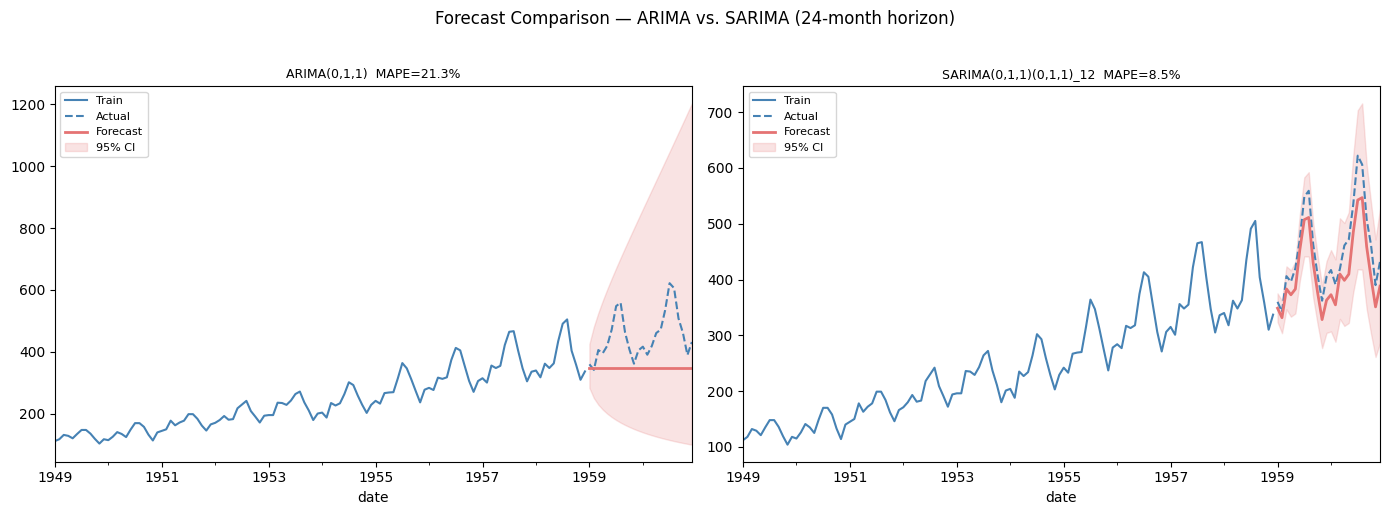

In [5]:
# ── Compare ARIMA vs. SARIMA information criteria ─────────────────────────
print(f"\nModel comparison (lower AIC/BIC = better):")
print(f"{'Model':<30}  {'AIC':>10}  {'BIC':>10}  {'Log-lik':>10}")
print("-" * 65)
for name, model in [
    ("ARIMA(0,1,1)",                  arima_best),
    ("SARIMA(0,1,1)(0,1,1)_12",       sarima_011_011),
]:
    print(f"{name:<30}  {model.aic:>10.2f}  {model.bic:>10.2f}  {model.llf:>10.2f}")

# ── SARIMA forecast ───────────────────────────────────────────────────────
sarima_fc = sarima_011_011.get_forecast(steps=HOLDOUT)
sarima_mean    = np.exp(sarima_fc.predicted_mean)
sarima_ci      = np.exp(sarima_fc.conf_int(alpha=0.05))

mae_sarima  = mean_absolute_error(test_orig, sarima_mean)
rmse_sarima = np.sqrt(mean_squared_error(test_orig, sarima_mean))
mape_sarima = np.mean(np.abs((test_orig.values - sarima_mean.values) / test_orig.values)) * 100

print(f"\nSARIMA(0,1,1)(0,1,1)_12 — 24-month out-of-sample forecast:")
print(f"  MAE  : {mae_sarima:.2f} thousand passengers")
print(f"  RMSE : {rmse_sarima:.2f} thousand passengers")
print(f"  MAPE : {mape_sarima:.2f}%")

# ── Side-by-side forecast comparison plot ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (fc_m, fc_c, title) in zip(axes, [
    (fc_mean_orig, fc_ci_orig,   f"ARIMA(0,1,1)  MAPE={mape:.1f}%"),
    (sarima_mean,  sarima_ci,    f"SARIMA(0,1,1)(0,1,1)_12  MAPE={mape_sarima:.1f}%"),
]):
    train_orig.plot(ax=ax, color="steelblue", lw=1.5, label="Train")
    test_orig.plot(ax=ax, color="steelblue",  lw=1.5, linestyle="--", label="Actual")
    fc_m.plot(ax=ax, color="#E57373", lw=2, label="Forecast")
    ax.fill_between(fc_c.index, fc_c.iloc[:, 0], fc_c.iloc[:, 1],
                    color="#E57373", alpha=0.2, label="95% CI")
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=8)

plt.suptitle("Forecast Comparison — ARIMA vs. SARIMA (24-month horizon)", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "ch03_sarima_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### SARIMA Residual Diagnostics

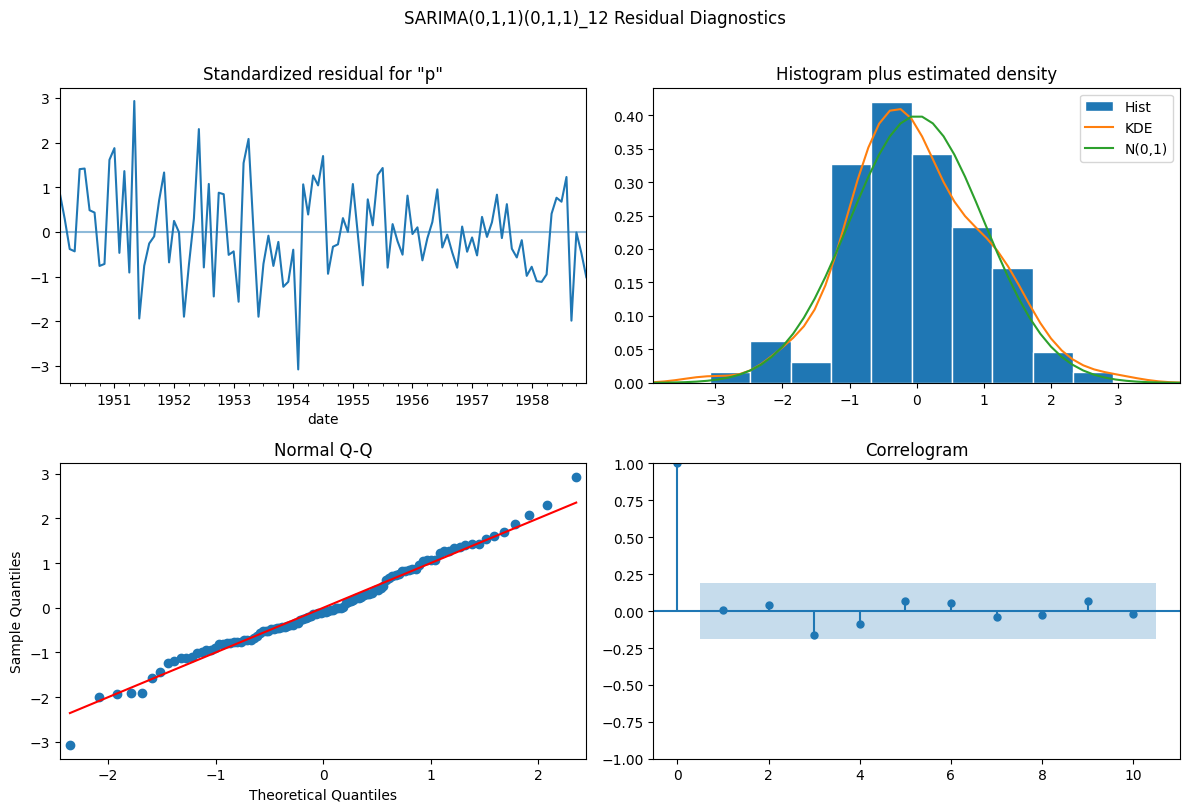

Ljung-Box test on SARIMA(0,1,1)(0,1,1)_12 residuals:
    lb_stat  lb_pvalue
6    0.1572     0.9999
12  22.4743     0.0325
18  22.5774     0.2074
24  22.6533     0.5403


In [6]:
fig = sarima_011_011.plot_diagnostics(figsize=(12, 8))
fig.suptitle("SARIMA(0,1,1)(0,1,1)_12 Residual Diagnostics", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / "ch03_sarima_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

lb_sarima = acorr_ljungbox(sarima_011_011.resid.dropna(),
                           lags=[6, 12, 18, 24], return_df=True)
print("Ljung-Box test on SARIMA(0,1,1)(0,1,1)_12 residuals:")
print(lb_sarima.round(4).to_string())

## Evaluation and Forecast Comparison

### Comprehensive Model Comparison

In [7]:
# ── Naive seasonal baseline (last observed same-season value) ─────────────
def seasonal_naive_forecast(train, test_len, season_period):
    last_season = train.values[-season_period:]
    reps = int(np.ceil(test_len / season_period))
    return np.tile(last_season, reps)[:test_len]

naive_fc_log = seasonal_naive_forecast(train_air, HOLDOUT, 12)
naive_fc     = np.exp(naive_fc_log)

mae_naive  = mean_absolute_error(test_orig, naive_fc)
rmse_naive = np.sqrt(mean_squared_error(test_orig, naive_fc))
mape_naive = np.mean(np.abs((test_orig.values - naive_fc) / test_orig.values)) * 100

# ── Summary comparison table ───────────────────────────────────────────────
print("=" * 65)
print(f"{'Model':<35}  {'MAE':>8}  {'RMSE':>8}  {'MAPE':>7}")
print("=" * 65)
for name, mae_v, rmse_v, mape_v in [
    ("Seasonal Naïve",              mae_naive,   rmse_naive,  mape_naive),
    ("ARIMA(0,1,1)",                mae,         rmse,        mape),
    ("SARIMA(0,1,1)(0,1,1)_12",    mae_sarima,  rmse_sarima, mape_sarima),
]:
    print(f"  {name:<33}  {mae_v:>8.2f}  {rmse_v:>8.2f}  {mape_v:>6.2f}%")
print("=" * 65)

Model                                     MAE      RMSE     MAPE
  Seasonal Naïve                        71.25     76.99   15.52%
  ARIMA(0,1,1)                         105.08    128.53   21.30%
  SARIMA(0,1,1)(0,1,1)_12               39.44     43.18    8.52%


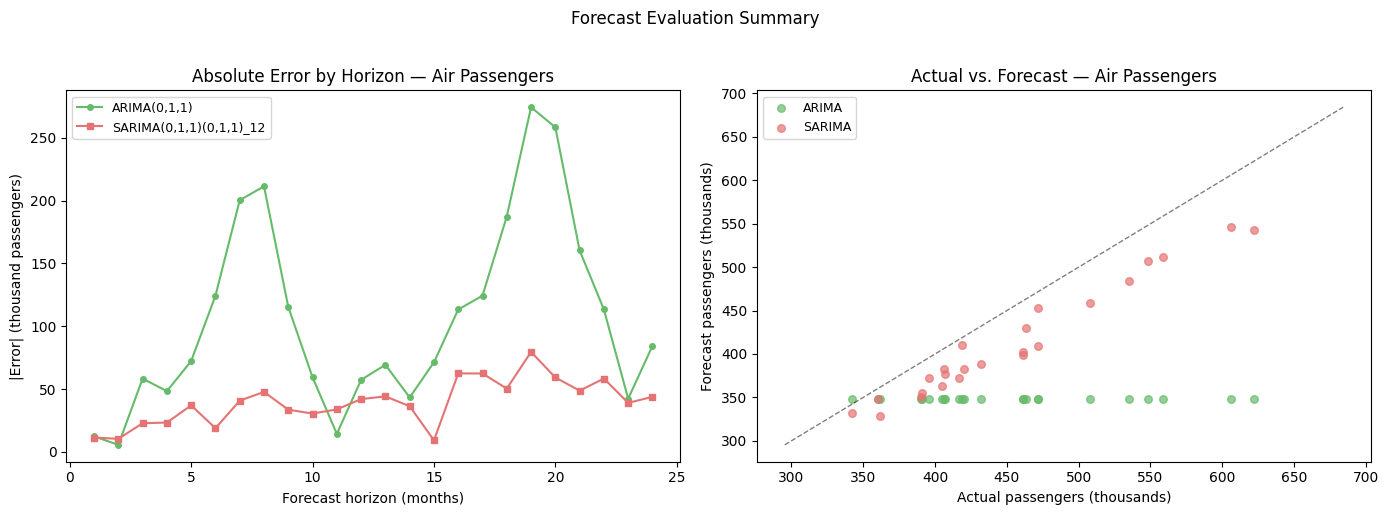

In [8]:
# ── Visual summary: error by forecast horizon ─────────────────────────────
horizon_errors_sarima = np.abs(test_orig.values - sarima_mean.values)
horizon_errors_arima  = np.abs(test_orig.values - fc_mean_orig.values)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, HOLDOUT + 1), horizon_errors_arima,
             color="#66BB6A", lw=1.5, label="ARIMA(0,1,1)", marker="o", ms=4)
axes[0].plot(range(1, HOLDOUT + 1), horizon_errors_sarima,
             color="#E57373", lw=1.5, label="SARIMA(0,1,1)(0,1,1)_12",
             marker="s", ms=4)
axes[0].set_xlabel("Forecast horizon (months)")
axes[0].set_ylabel("|Error| (thousand passengers)")
axes[0].set_title("Absolute Error by Horizon — Air Passengers")
axes[0].legend(fontsize=9)

for model_name, preds, color in [
    ("ARIMA",  fc_mean_orig.values, "#66BB6A"),
    ("SARIMA", sarima_mean.values,  "#E57373")
]:
    axes[1].scatter(test_orig.values, preds,
                    c=color, alpha=0.7, s=30, label=model_name)

lims = [min(test_orig.min(), fc_mean_orig.min(), sarima_mean.min()) * 0.9,
        max(test_orig.max(), fc_mean_orig.max(), sarima_mean.max()) * 1.1]
axes[1].plot(lims, lims, "k--", lw=1, alpha=0.5)
axes[1].set_xlabel("Actual passengers (thousands)")
axes[1].set_ylabel("Forecast passengers (thousands)")
axes[1].set_title("Actual vs. Forecast — Air Passengers")
axes[1].legend(fontsize=9)

plt.suptitle("Forecast Evaluation Summary", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "ch03_eval_summary.png", dpi=150, bbox_inches="tight")
plt.show()